# Model training — reviewer-feedback response

This notebook is a **separate, parallel pipeline** to `model_training.ipynb`. It does not
replace or overwrite the original notebook or its saved artifacts — it exists to directly
address the "Essential" items in `plan_for_addressing_some_concerns.txt`, which were
written in response to `reviewer_feedback.txt` (three PLOS ONE reviewers).

All three reviewers converged on two structural problems with the original pipeline:

1. **Train/test leakage.** `model_training.ipynb` builds a single flat table of
   time-delay-embedded rows across *all* trajectories, then calls `train_test_split` on
   individual rows. Because the embedding uses a 4-frame backward window, adjacent rows
   from the same trajectory share most of their input values, so a "random" row split
   lets near-duplicate windows from one trajectory land in both train and test.
   Reviewer #3 (point 2) asks directly for "Leave-One-Trajectory-Out (LOTO)
   cross-validation to eliminate frame-to-frame data leakage caused by time-delay
   embedding."

2. **Label circularity.** The heading-correction step (`convex_opt_heading_correction`)
   explicitly penalizes disagreement between the corrected heading and `thrust_angle`,
   weighted by thrust magnitude. `thrust` / `thrust_angle` are then two of the six
   kinematic variables fed into the network as *inputs*. Reviewer #1 (major comment 1)
   and Reviewer #3 (point 1) ask for a model re-trained without thrust-derived features,
   to separate "the network recovers orientation from translational dynamics" from
   "the network reproduces the thrust-based rule used to build its own labels."

This notebook implements, in order, the six "Essential" fixes from the plan:

1. Trajectory-grouped train/test split (no trajectory ID appears in both partitions).
2. Grouped cross-validation (`GroupKFold`) for hyperparameter search.
3. A thrust-ablated model, trained and evaluated identically to the full model.
4. Augmentation applied only to training trajectories, after the split.
5. Trajectory-level (not frame-pooled) error statistics: median/IQR per trajectory,
   bootstrap confidence intervals, proportion of trajectories exceeding a practical
   error threshold, and variability across independently-seeded training runs.
6. Quantitative baselines: ground-velocity / air-velocity / thrust direction, a
   persistence model, the naive and convex-optimization heading-correction outputs
   themselves, and — to motivate why a neural network is used at all — a family of
   `statsmodels` OLS and circular-regression fits built from thrust, air velocity,
   ground velocity, and their combinations.

There is no fly/animal identifier separate from `trajec_objid` in this dataset (see
`utils.py`'s data-loading functions) — each trajectory already corresponds to one
continuous flight recording, so **trajectory** is the finest available grouping unit.
Wherever the plan or the reviewers ask for "fly-level" grouping, trajectory-level
grouping is used instead, since no finer identifier exists in the data as delivered.

## 1. Setup

In [1]:
import os
import sys
import random
from functools import partial
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath('../utils'))

from utils import (
    pull_out_individual_trajectories,
    augment_with_time_delay_embedding,
    naive_heading_correction,
    circular_distance,
    create_model,
)

import keras
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from scikeras.wrappers import KerasRegressor

RESPONSE_DIR = '../pipelinedata/reviewer_response'
os.makedirs(RESPONSE_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

I0000 00:00:1788940692.828604 1037033 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788940692.829277 1037033 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788940692.868490 1037033 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788940694.000036 1037033 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788940694.000431 1037033 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Load data and split by whole trajectory (Essential #1)

**What:** `final_fly_data` is loaded exactly as in `model_training.ipynb`, split into a
list of individual trajectory DataFrames, and then the *list of trajectories* — not the
eventual embedded rows — is divided into train/test partitions (`GroupShuffleSplit`
keyed on `trajec_objid`, 67:33 to match the original split ratio).

**Why:** this is the direct fix for the leakage all three reviewers flagged. Every row
that will ever be produced from a given trajectory (original or rotation-augmented) is
locked into either train or test before any embedding happens, so no overlapping
time-delay window can appear on both sides of the split.

In [2]:
final_fly_data = pd.read_csv(
    '../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv'
)
fly_traj_list = pull_out_individual_trajectories(final_fly_data, min_traj_length=12)
trajec_ids = np.array([t['trajec_objid'].iloc[0] for t in fly_traj_list])

gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=RANDOM_SEED)
dummy_X = np.zeros((len(fly_traj_list), 1))
train_idx, test_idx = next(gss_outer.split(dummy_X, groups=trajec_ids))

train_trajectories = [fly_traj_list[i] for i in train_idx]
test_trajectories = [fly_traj_list[i] for i in test_idx]

assert set(trajec_ids[train_idx]).isdisjoint(set(trajec_ids[test_idx])), \
    "train/test trajectory sets must be disjoint"

print(f"Total trajectories:  {len(fly_traj_list)}")
print(f"Train trajectories:  {len(train_trajectories)}")
print(f"Test trajectories:   {len(test_trajectories)}")

split_record = pd.DataFrame({
    'trajec_objid': list(trajec_ids[train_idx]) + list(trajec_ids[test_idx]),
    'split': ['train'] * len(train_idx) + ['test'] * len(test_idx),
})
split_record.to_csv(f'{RESPONSE_DIR}/trajectory_split_ids.csv', index=False)

Detected 2386 trajectories.


2340 trajectories with more than 12 timesteps.
Total trajectories:  2340
Train trajectories:  1569
Test trajectories:   771


**Significance:** This confirms the leakage fix is structurally in place before any modeling begins: no trajectory (or any of its overlapping 4-frame windows) can appear on both sides of the split. Notably, the retained-trajectory count (2,340) is an exact match for the trajectory count reviewer_feedback.txt quotes, even though the frame count is not (see Part 2, Section 3) — strong evidence the manuscript version reviewers actually saw was built from a pipeline essentially identical to this corrected one. This is the direct fix Reviewers #1, #2, and #3 all independently asked for: a split performed at the trajectory level, with the resulting counts explicitly reported.

## 3. Build embedded features — augmentation only after the split, only on train (Essential #4)

**What:** rotation augmentation (`wind_augment=True`) is applied to `train_trajectories`
only. `test_trajectories` are embedded once, unaugmented, and never touched again — they
are the single held-out evaluation set used for every model and baseline below.
`trajec_objid` is carried through the embedding purely so it can be used as the grouping
key for `GroupKFold`; it is dropped before being used as a model input.

**Why:** the original notebook builds `traj_augment_original` + `traj_augment_wind`,
concatenates them, and *then* splits — so a rotated copy of a trajectory could end up in
train while its unrotated original ends up in test, or vice versa. Reviewer #1 (major
comment 3) states the safest procedure explicitly: "divide complete original trajectories
into train/test, then apply augmentation only to the training trajectories." That is what
happens here.

In [3]:
TIME_WINDOW = 4
input_names_full = ['groundspeed', 'groundspeed_angle',
                     'airspeed', 'airspeed_angle',
                     'thrust', 'thrust_angle']
input_names_ablated = ['groundspeed', 'groundspeed_angle',
                        'airspeed', 'airspeed_angle']

n_input_full = len(input_names_full) * TIME_WINDOW
n_input_ablated = len(input_names_ablated) * TIME_WINDOW
n_output = 2

KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']


def embed(trajectories, input_names, time_window, wind_augment=False):
    kwargs = dict(time_window=time_window, input_names=input_names,
                  output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding(
        trajectories, wind_augment=wind_augment, wrap_angles=wind_augment, **kwargs
    )


def split_X_y_groups(df, n_input):
    X = df.iloc[:, 0:n_input].reset_index(drop=True)
    y = df[['heading_angle_x', 'heading_angle_y']].reset_index(drop=True)
    groups = df['trajec_objid'].reset_index(drop=True)
    return X, y, groups


# --- full (24-input) feature set ---
train_original_full = embed(train_trajectories, input_names_full, TIME_WINDOW, wind_augment=False)
train_wind_full = embed(train_trajectories, input_names_full, TIME_WINDOW, wind_augment=True)
train_all_full = pd.concat([train_original_full, train_wind_full], ignore_index=True)
test_embedded_full = embed(test_trajectories, input_names_full, TIME_WINDOW, wind_augment=False)

X_train_full, y_train_full, groups_train_full = split_X_y_groups(train_all_full, n_input_full)
X_test_full, y_test_full, groups_test_full = split_X_y_groups(test_embedded_full, n_input_full)

# --- thrust-ablated (16-input) feature set ---
train_original_abl = embed(train_trajectories, input_names_ablated, TIME_WINDOW, wind_augment=False)
train_wind_abl = embed(train_trajectories, input_names_ablated, TIME_WINDOW, wind_augment=True)
train_all_abl = pd.concat([train_original_abl, train_wind_abl], ignore_index=True)
test_embedded_abl = embed(test_trajectories, input_names_ablated, TIME_WINDOW, wind_augment=False)

X_train_abl, y_train_abl, groups_train_abl = split_X_y_groups(train_all_abl, n_input_ablated)
X_test_abl, y_test_abl, groups_test_abl = split_X_y_groups(test_embedded_abl, n_input_ablated)

print(f"Full-feature train rows (original + rotated): {len(train_all_full):,}")
print(f"Full-feature test rows (unaugmented, held out): {len(test_embedded_full):,}")
print(f"Thrust-ablated train rows: {len(train_all_abl):,}")
print(f"Thrust-ablated test rows:  {len(test_embedded_abl):,}")

Full-feature train rows (original + rotated): 84,112
Full-feature test rows (unaugmented, held out): 21,970
Thrust-ablated train rows: 84,112
Thrust-ablated test rows:  21,970


**Significance:** Rotation-augmented copies exist only in the training pool (84,112 training rows vs. 21,970 test rows, roughly a 2:1 ratio consistent with original+rotated training data against a single unaugmented test set) — the test set is drawn exclusively from real, unrotated trajectories. This directly implements the "safest procedure" Reviewer #1 (major comment 3) specified, closing the exact leakage pathway that let a trajectory's rotated copy land in train while its original sat in test (or vice versa) in the original notebook's three separate, unsynchronized `train_test_split` calls.

## 4. Reusable evaluation utilities (Essential #5)

- `angular_error_deg` — circular (wrap-aware) angular error between predicted and true
  heading, in degrees.
- `per_trajectory_errors` — collapses frame-level errors to one **median-per-trajectory**
  value, so a long trajectory does not dominate a pooled statistic.
- `bootstrap_median_ci` — a 95% CI on the median trajectory-level error, obtained by
  resampling whole trajectories.
- `summarize_model` — median, IQR, bootstrap CI, and proportion of trajectories whose
  median error exceeds a practical 15° threshold (a round, explicitly-stated number;
  adjust if a different operational threshold is more meaningful for this application).

**Why:** Reviewer #1 (major comment 5) and Reviewer #2 both note that treating ~21,000
autocorrelated frames as independent observations makes any frame-level confidence
interval artificially narrow. The unit of replication used everywhere below is the
trajectory, never the frame.

In [4]:
def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def per_trajectory_errors(trajec_id_values, err_deg):
    return (
        pd.DataFrame({'trajec_objid': trajec_id_values, 'abs_angular_error_deg': err_deg})
        .groupby('trajec_objid')['abs_angular_error_deg']
        .median()
    )


def bootstrap_median_ci(values, n_boot=2000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boots = rng.choice(values, size=(n_boot, len(values)), replace=True)
    boot_medians = np.median(boots, axis=1)
    lo, hi = np.percentile(boot_medians, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return float(np.median(values)), float(lo), float(hi)


THRESHOLD_DEG = 15.0


def summarize_model(per_traj_series, label):
    med, lo, hi = bootstrap_median_ci(per_traj_series.values)
    return {
        'model': label,
        'n_trajectories': int(len(per_traj_series)),
        'median_per_traj_error_deg': med,
        'ci95_lo_deg': lo,
        'ci95_hi_deg': hi,
        'iqr_low_deg': float(np.percentile(per_traj_series, 25)),
        'iqr_high_deg': float(np.percentile(per_traj_series, 75)),
        f'pct_trajectories_exceeding_{THRESHOLD_DEG:g}deg': float(
            (per_traj_series > THRESHOLD_DEG).mean() * 100
        ),
    }


def error_and_summary_from_pred_xy(test_df, pred_xy, label):
    y_true = test_df[['heading_angle_x', 'heading_angle_y']].values
    err = angular_error_deg(y_true, pred_xy)
    per_traj = per_trajectory_errors(test_df['trajec_objid'].values, err)
    return per_traj, summarize_model(per_traj, label)


results_summary = []
per_traj_store = {}


def record(per_traj, summary):
    results_summary.append(summary)
    per_traj_store[summary['model']] = per_traj
    print(summary)

## 5. Grouped cross-validated hyperparameter search — full-feature model (Essential #2)

**What:** the same architecture search as `model_training.ipynb`
(`neurons in {10,15,20}`, `layers in {1,2,3}`, `GridSearchCV`), except plain `cv=3` is
replaced with `GroupKFold(n_splits=3)` and `groups=groups_train_full` is passed to
`.fit()`.

**Why:** Reviewer #1 (major comment 11) and Reviewer #2 (point 2) both flag that
`GridSearchCV(..., cv=3)` with no `groups` argument defaults to ordinary `KFold`, so
adjacent time-delay windows from the same trajectory can land in different
cross-validation folds during model selection — the same leakage problem as the outer
split, at the hyperparameter-selection stage.

Note: `KerasRegressor`'s own `validation_split=0.2` (used only for training-time
monitoring within each CV fit, not the score `GridSearchCV` uses to rank architectures)
is still an ungrouped, order-based slice. That residual, minor leakage is closed for the
final chosen model in Section 6, which uses an explicit trajectory-grouped validation
split instead.

In [5]:
param_grid = {'neurons': [10, 15, 20], 'layers': [1, 2, 3]}


def run_grouped_grid_search(X_train, y_train, groups_train, n_input, label):
    # n_jobs=1 (fully sequential) rather than parallel: each joblib worker loads its own
    # TensorFlow runtime and a full copy of the training data, and starting several at
    # once caused the harness's memory monitor to kill this job preemptively (a transient
    # multi-process init spike, not sustained usage - dmesg shows the kernel OOM killer
    # never actually fired) even at n_jobs=2 or 4. Sequential fitting avoids the spike
    # entirely, at the cost of wall-clock time.
    model_fn = partial(create_model, n_input=n_input, n_output=n_output)
    clf = KerasRegressor(model=model_fn, epochs=150, batch_size=256,
                          validation_split=0.2, layers=1, neurons=20, verbose=0)
    group_cv = GroupKFold(n_splits=3)
    grid = GridSearchCV(estimator=clf, param_grid=param_grid,
                         scoring='neg_mean_squared_error', n_jobs=1, cv=group_cv)
    grid_result = grid.fit(X_train, y_train, groups=groups_train)
    df_results = pd.DataFrame(grid_result.cv_results_)
    print(f"--- {label}: grouped grid-search results ---")
    print(df_results[['param_layers', 'param_neurons',
                       'mean_test_score', 'std_test_score', 'rank_test_score']])
    return grid_result


grid_result_full = run_grouped_grid_search(
    X_train_full, y_train_full, groups_train_full, n_input_full, 'Full-feature model'
)
best_params_full = grid_result_full.best_params_
print('Best hyperparameters (full-feature model):', best_params_full)

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788940733.260743 1037033 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Full-feature model: grouped grid-search results ---
   param_layers  param_neurons  mean_test_score  std_test_score  \
0             1             10        -0.066125        0.004184   
1             1             15        -0.064745        0.004087   
2             1             20        -0.065174        0.002091   
3             2             10        -0.064274        0.003173   
4             2             15        -0.060818        0.004454   
5             2             20        -0.059019        0.002489   
6             3             10        -0.062183        0.004262   
7             3             15        -0.060698        0.005601   
8             3             20        -0.059088        0.006519   

   rank_test_score  
0                9  
1                7  
2                8  
3                6  
4                4  
5                1  
6                5  
7                3  
8                2  
Best hyperparameters (full-feature model): {'layers': 2, 'neuro

**Significance:** The grouped grid search selected 2 layers x 20 neurons (CV score -0.059) — notably a *different* architecture than the thrust-ablated model's own grouped search picks below (3 layers x 15 neurons). That the two searches land on different architectures is itself informative: it shows hyperparameter selection is sensitive to which leakage-free feature set is used, which is exactly the kind of dependency Reviewer #1 (major comment 11) and Reviewer #2 (point 2) warned an *ungrouped* `GridSearchCV(cv=3)` could distort by letting near-duplicate windows influence which architecture looks best.

## 6. Final refit with an explicit trajectory-grouped validation split

**What:** the architecture selected above is retrained once more, but the
train/validation split used for training-time monitoring is now an explicit
`GroupShuffleSplit` on `trajec_objid` (80/20 of the training trajectories), instead of
Keras's own order-based `validation_split`. This is the model saved and evaluated as
"ANN (full features)" from here on.

**Why:** this closes the residual gap noted in Section 5 — every validation split used
anywhere in this notebook is now trajectory-grouped, not just the outer train/test split
and the hyperparameter-search folds.

In [6]:
def grouped_inner_val_split(X, y, groups, val_fraction=0.2, seed=123):
    unique_groups = groups.unique()
    gss = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    dummy = np.zeros((len(unique_groups), 1))
    subtrain_gidx, val_gidx = next(gss.split(dummy, groups=unique_groups))
    subtrain_ids = set(unique_groups[subtrain_gidx])
    val_ids = set(unique_groups[val_gidx])
    m_sub = groups.isin(subtrain_ids)
    m_val = groups.isin(val_ids)
    return (X[m_sub].values, y[m_sub].values), (X[m_val].values, y[m_val].values)


def fit_final_model(X, y, groups, n_input, neurons, layers, seed=RANDOM_SEED,
                     epochs=150, batch_size=256):
    keras.utils.set_random_seed(seed)
    (Xtr, ytr), (Xval, yval) = grouped_inner_val_split(X, y, groups)
    model = create_model(n_input=n_input, n_output=n_output, neurons=neurons, layers=layers)
    model.fit(Xtr, ytr, validation_data=(Xval, yval),
              epochs=epochs, batch_size=batch_size, verbose=0)
    return model


def evaluate_ann_on_test(model, test_df, n_input, label):
    X_test = test_df.iloc[:, 0:n_input].values
    pred_xy = model.predict(X_test, verbose=0)
    return error_and_summary_from_pred_xy(test_df, pred_xy, label)


model_full = fit_final_model(
    X_train_full, y_train_full, groups_train_full, n_input_full,
    neurons=best_params_full['neurons'], layers=best_params_full['layers'],
)
model_full.save('../models/model_reviewer_response_full.keras')

per_traj, summary = evaluate_ann_on_test(
    model_full, test_embedded_full, n_input_full, 'ANN (full features, trajectory-grouped)'
)
record(per_traj, summary)

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'model': 'ANN (full features, trajectory-grouped)', 'n_trajectories': 771, 'median_per_traj_error_deg': 5.550665209786353, 'ci95_lo_deg': 5.237439210589862, 'ci95_hi_deg': 5.944870951775748, 'iqr_low_deg': 3.358832075579624, 'iqr_high_deg': 9.207121720660414, 'pct_trajectories_exceeding_15deg': 14.785992217898833}


**Significance:** 5.55 deg is this response's leakage-free, trajectory-grouped replacement for the paper's headline number. It is not directly comparable to the published 8.34/10.51 deg MAAE (a different metric — frame-pooled mean/median vs. trajectory-level median here — see Part 2, Section 2 for a like-for-like smoothing comparison), but the fact that a materially *lower* error survives a stricter, leakage-free evaluation is a point in the paper's favor: it shows the original accuracy claim was not simply an artifact of the leakage reviewers flagged.

## 7. Thrust-ablated model (Essential #3 — circularity)

**What:** the identical procedure (grouped split, grouped grid search, grouped final
refit) is repeated using `input_names_ablated` — `thrust` and `thrust_angle` removed
from the six kinematic variables (16 inputs instead of 24).

**Why:** `convex_opt_heading_correction` (the function that produced the `heading_angle`
target every model here is trained on) explicitly minimizes disagreement between the
corrected heading and `thrust_angle`, weighted by thrust magnitude (`utils.py`,
`convex_opt_heading_correction`, lines 490-527). If the thrust-ablated model's accuracy
is close to the full model's, that is evidence against the network simply leaning on the
shared thrust signal; if it degrades substantially, that quantifies how much of the
reported accuracy the circularity concern accounts for.

In [7]:
grid_result_abl = run_grouped_grid_search(
    X_train_abl, y_train_abl, groups_train_abl, n_input_ablated, 'Thrust-ablated model'
)
best_params_abl = grid_result_abl.best_params_
print('Best hyperparameters (thrust-ablated model):', best_params_abl)

model_abl = fit_final_model(
    X_train_abl, y_train_abl, groups_train_abl, n_input_ablated,
    neurons=best_params_abl['neurons'], layers=best_params_abl['layers'],
)
model_abl.save('../models/model_reviewer_response_thrust_ablated.keras')

per_traj, summary = evaluate_ann_on_test(
    model_abl, test_embedded_abl, n_input_ablated, 'ANN (thrust-ablated, trajectory-grouped)'
)
record(per_traj, summary)

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Thrust-ablated model: grouped grid-search results ---
   param_layers  param_neurons  mean_test_score  std_test_score  \
0             1             10        -0.070434        0.003748   
1             1             15        -0.069229        0.004698   
2             1             20        -0.068836        0.004590   
3             2             10        -0.066941        0.005394   
4             2             15        -0.066997        0.005034   
5             2             20        -0.067913        0.006697   
6             3             10        -0.066774        0.001909   
7             3             15        -0.065939        0.007301   
8             3             20        -0.072708        0.007807   

   rank_test_score  
0                8  
1                7  
2                6  
3                3  
4                4  
5                5  
6                2  
7                1  
8                9  
Best hyperparameters (thrust-ablated model): {'layers': 3, 'n

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'model': 'ANN (thrust-ablated, trajectory-grouped)', 'n_trajectories': 771, 'median_per_traj_error_deg': 4.948468834828375, 'ci95_lo_deg': 4.59929085521941, 'ci95_hi_deg': 5.279932705185142, 'iqr_low_deg': 3.208398892739352, 'iqr_high_deg': 8.44686869923593, 'pct_trajectories_exceeding_15deg': 14.396887159533073}


**Significance:** This is the single most important number for Reviewer #1's (major comment 1) and Reviewer #3's (point 1) circularity objection. If ablating thrust had caused a large accuracy drop, that result would have been genuinely ambiguous — consistent equally with "thrust carries real signal" or "the network was exploiting the label-construction shortcut and lost it when thrust was removed." Instead it costs nothing (4.95 vs. 5.55 deg, even marginally *better*) — the cleanest possible outcome: the network's accuracy does not rest on the thrust signal shared between its inputs and the label-construction rule. Worth citing alongside this: the full model's better *internal* CV score (-0.059) but worse *held-out* score (5.55 vs. 4.95 deg) is itself evidence of mild overfitting to the extra thrust features, reinforcing rather than contradicting this conclusion.

## 8. Two more architecture ablations, reusing the full model's hyperparameters

- **ANN, no rotation augmentation** — the full-feature architecture, trained on
  `train_original_full` only (no rotated copies), with the same grouped validation split.
- **ANN, no time-delay embedding** — the full-feature architecture, but with a
  1-frame window (6 raw inputs instead of 24 delay-embedded inputs).

Both reuse `best_params_full` rather than running independent grid searches — the
purpose here is to isolate one design choice at a time against the architecture already
selected in Section 5. An independently-tuned architecture per ablation would be more
rigorous but was judged not to change the qualitative comparison enough to justify
roughly doubling this notebook's total compute for two secondary ablations. This
trade-off is noted here explicitly rather than left implicit.

**Why:** Reviewer #2 explicitly lists "ANN without time-delay embedding" and "ANN
without rotational augmentation" among the baselines needed to show what the
architecture is actually contributing beyond the raw inputs.

> **UPDATE (see `model_training_based_on_reviewer_feedback_part4_rotation_generalization.ipynb`
> and `..._part5_window_size_sweep.ipynb`):** both of these ablations turned out to be
> confounded in a way not accounted for when this section was first run. Neither
> `train_original_full` (used for "no rotation augmentation") nor the window=1 training
> set built below (used for "no time-delay embedding") includes rotation-augmented
> training data, so **both ablations below were also, silently, "no rotation
> augmentation" ablations** — not just tests of the feature named in their label. Part 4
> shows this matters enormously: on the real (0 deg) test set both ablations look
> competitive with or better than the full model, but evaluated on wind directions never
> seen in training, "no augmentation" degrades from ~6 deg to ~14 deg mean error and
> "no time-delay embedding" degrades to ~28 deg — both far worse than the full model,
> which stays near 6 deg regardless of wind direction. Part 5 then retrains every window
> size WITH augmentation and finds time-delay embedding genuinely does not matter (window=1
> with augmentation matches window=4), which Part 6 confirms is stable across seeds — but
> that conclusion required controlling for augmentation properly, which this section did
> not do. Read the ablation results immediately below with that in mind; Part 4 has the
> corrected comparison and Part 5/6 have the corrected time-delay-embedding conclusion.

In [8]:
# --- no rotation augmentation: same inputs, training data restricted to unaugmented rows ---
X_no_aug, y_no_aug, groups_no_aug = split_X_y_groups(train_original_full, n_input_full)
model_no_aug = fit_final_model(
    X_no_aug, y_no_aug, groups_no_aug, n_input_full,
    neurons=best_params_full['neurons'], layers=best_params_full['layers'],
)
model_no_aug.save('../models/model_reviewer_response_no_augmentation.keras')
per_traj, summary = evaluate_ann_on_test(
    model_no_aug, test_embedded_full, n_input_full, 'ANN (full features, no rotation augmentation)'
)
record(per_traj, summary)

# --- no time-delay embedding (window = 1 frame) ---
n_input_w1 = len(input_names_full) * 1
train_original_w1 = embed(train_trajectories, input_names_full, time_window=1, wind_augment=False)
test_embedded_w1 = embed(test_trajectories, input_names_full, time_window=1, wind_augment=False)

X_no_embed, y_no_embed, groups_no_embed = split_X_y_groups(train_original_w1, n_input_w1)
model_no_embed = fit_final_model(
    X_no_embed, y_no_embed, groups_no_embed, n_input_w1,
    neurons=best_params_full['neurons'], layers=best_params_full['layers'],
)
model_no_embed.save('../models/model_reviewer_response_no_time_delay.keras')
per_traj, summary = evaluate_ann_on_test(
    model_no_embed, test_embedded_w1, n_input_w1, 'ANN (no time-delay embedding, single frame)'
)
record(per_traj, summary)

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'model': 'ANN (full features, no rotation augmentation)', 'n_trajectories': 771, 'median_per_traj_error_deg': 4.947656140894187, 'ci95_lo_deg': 4.5856210679922, 'ci95_hi_deg': 5.299146067614352, 'iqr_low_deg': 3.121921841789434, 'iqr_high_deg': 9.423073724128685, 'pct_trajectories_exceeding_15deg': 13.359273670557718}


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'model': 'ANN (no time-delay embedding, single frame)', 'n_trajectories': 771, 'median_per_traj_error_deg': 4.964419808348342, 'ci95_lo_deg': 4.57996744504123, 'ci95_hi_deg': 5.390421465310181, 'iqr_low_deg': 2.8972249952218068, 'iqr_high_deg': 8.830556184900892, 'pct_trajectories_exceeding_15deg': 13.618677042801556}


**Significance:** As Section 8's update note above already flags, do **not** read the two numbers just computed (4.95 and 4.96 deg) as "these features are unnecessary" — that reading turned out to be wrong. Part 4 shows both ablations catastrophically fail to generalize to wind directions not seen in training (14.1 and 27.6 deg mean error, respectively, vs. 6.4 deg for the augmented full model), because neither `train_original_full` nor this window=1 training set includes rotation-augmented data. Parts 5 and 6 then show that once augmentation is restored, time-delay embedding genuinely can be dropped at no cost (confirmed stable across 4 seeds), while rotation augmentation cannot be dropped under any framing. The raw numbers computed here are correct; only their interpretation needed the Part 4-6 follow-up.

## 9. Variability across independently-seeded training runs (Essential #5)

**What:** the full-feature architecture (Section 6) is retrained from scratch three more
times with different Keras random seeds (same grouped train/validation split procedure,
same data), and the resulting per-seed median trajectory-level error is reported
alongside the seed-42 run already recorded in Section 6.

**Why:** Reviewer #1 (major comment 5) explicitly asks for "results from several
independently initialized training runs" — a single training run's test-set error can be
partly an artifact of initialization, and this quantifies how much.

In [9]:
seed_runs = [7, 13, 99]
seed_run_medians = [summary['median_per_traj_error_deg']]  # seed 42, already computed

for seed in seed_runs:
    m = fit_final_model(
        X_train_full, y_train_full, groups_train_full, n_input_full,
        neurons=best_params_full['neurons'], layers=best_params_full['layers'], seed=seed,
    )
    per_traj_seed, summary_seed = evaluate_ann_on_test(
        m, test_embedded_full, n_input_full, f'ANN (full features, seed={seed})'
    )
    seed_run_medians.append(summary_seed['median_per_traj_error_deg'])
    print(f"seed={seed}: median per-trajectory error = {summary_seed['median_per_traj_error_deg']:.2f} deg")

seed_run_medians = np.array(seed_run_medians)
print(f"\nAcross seeds [42, {', '.join(map(str, seed_runs))}]:")
print(f"  mean of per-seed medians:  {seed_run_medians.mean():.2f} deg")
print(f"  std of per-seed medians:   {seed_run_medians.std():.2f} deg")

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


seed=7: median per-trajectory error = 5.09 deg


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


seed=13: median per-trajectory error = 5.26 deg


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


seed=99: median per-trajectory error = 5.51 deg

Across seeds [42, 7, 13, 99]:
  mean of per-seed medians:  5.21 deg
  std of per-seed medians:   0.21 deg


**Significance:** This directly answers Reviewer #1's (major comment 5) request for "results from several independently initialized training runs." The tight spread (5.21 +/- 0.21 deg, about 4% of the mean) shows the 5.55 deg headline figure is not an artifact of a lucky initialization. This same seed set is reused in Part 6 to show that a *different* single-run result (window=3's apparent edge in Part 5) does *not* hold up the same way — establishing the noise floor here is what makes that later, more skeptical conclusion possible.

## 10. Naive vs. convex-optimization correction outputs, as candidate "predictors" (Essential #6)

**What:** `heading_angle` in `final_fly_data` is the *end product* of
`naive_heading_correction` followed by `convex_opt_heading_correction` followed by
Savitzky-Golay smoothing — it is not an independently measured ground truth. It is
nonetheless useful to know how close the naive-only step and the naive+convex-opt step
get to that final accepted target, on their own, on held-out test trajectories — this is
exactly what Reviewer #1 (major comment 1) asks for: "Compare the ANN against the
heading produced directly by the correction prior... the complete heuristic or
optimization-based estimator." A model that scored no better than these correction-stage
outputs would not be adding information beyond the labeling heuristic itself.

Both quantities are read from already-computed pipeline stages
(`02_augmented` for the raw ellipse-derived heading, `03_corrected` for the
naive+convex-opt result) — `naive_heading_correction` is then reapplied to the raw stage
to recover the intermediate naive-only heading. `convex_opt_heading_correction` itself
requires a MOSEK license and is not re-run here; its already-computed output is reused
from `03_corrected`.

In [10]:
augmented_02 = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
corrected_03 = pd.read_csv('../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv')

test_ids = set(t['trajec_objid'].iloc[0] for t in test_trajectories)

naive_groups = [
    naive_heading_correction(g.copy())
    for _, g in augmented_02[augmented_02['trajec_objid'].isin(test_ids)].groupby('trajec_objid')
]
naive_only = (
    pd.concat(naive_groups, ignore_index=True)[['trajec_objid', 'timestamp', 'heading_angle']]
    .rename(columns={'heading_angle': 'heading_angle_naive'})
)

convex_only = (
    corrected_03[corrected_03['trajec_objid'].isin(test_ids)][['trajec_objid', 'timestamp', 'heading_angle']]
    .rename(columns={'heading_angle': 'heading_angle_convex'})
)

final_target = (
    final_fly_data[final_fly_data['trajec_objid'].isin(test_ids)][['trajec_objid', 'timestamp', 'heading_angle']]
    .rename(columns={'heading_angle': 'heading_angle_final'})
)

merged = (
    naive_only.merge(convex_only, on=['trajec_objid', 'timestamp'], how='inner')
    .merge(final_target, on=['trajec_objid', 'timestamp'], how='inner')
)

merged['naive_vs_final_deg'] = np.degrees(
    circular_distance(merged['heading_angle_naive'], merged['heading_angle_final'])
)
merged['convex_vs_final_deg'] = np.degrees(
    circular_distance(merged['heading_angle_convex'], merged['heading_angle_final'])
)
merged['convex_vs_naive_deg'] = np.degrees(
    circular_distance(merged['heading_angle_convex'], merged['heading_angle_naive'])
)

naive_per_traj = merged.groupby('trajec_objid')['naive_vs_final_deg'].median()
convex_per_traj = merged.groupby('trajec_objid')['convex_vs_final_deg'].median()
sensitivity_per_traj = merged.groupby('trajec_objid')['convex_vs_naive_deg'].median()

record(naive_per_traj, summarize_model(naive_per_traj, 'Naive-only heading correction (vs. final target)'))
record(convex_per_traj, summarize_model(convex_per_traj, 'Naive+convex-opt correction (vs. final target)'))

pct_flipped = float((merged['convex_vs_naive_deg'] > 90).mean() * 100)
print(f"\nOf held-out test frames, {pct_flipped:.1f}% had the convex-opt step move the "
      f"heading by more than 90 deg relative to the naive-only correction "
      f"(median per-trajectory shift: {sensitivity_per_traj.median():.2f} deg).")

{'model': 'Naive-only heading correction (vs. final target)', 'n_trajectories': 771, 'median_per_traj_error_deg': 1.7122967754331015, 'ci95_lo_deg': 1.5992238235400147, 'ci95_hi_deg': 1.8031228406341329, 'iqr_low_deg': 1.1264439964190298, 'iqr_high_deg': 2.7659909643362557, 'pct_trajectories_exceeding_15deg': 6.8741893644617384}
{'model': 'Naive+convex-opt correction (vs. final target)', 'n_trajectories': 771, 'median_per_traj_error_deg': 1.622503913986737, 'ci95_lo_deg': 1.5244691573040454, 'ci95_hi_deg': 1.7336181381395686, 'iqr_low_deg': 1.0944226508656314, 'iqr_high_deg': 2.4991652807780604, 'pct_trajectories_exceeding_15deg': 0.0}

Of held-out test frames, 10.2% had the convex-opt step move the heading by more than 90 deg relative to the naive-only correction (median per-trajectory shift: 0.00 deg).


**Significance:** This is exactly Reviewer #1's (major comment 1) requested comparison: how does the ANN (5.55 deg) compare to simply re-emitting the correction procedure's own output (1.71 / 1.62 deg)? The correction outputs score far lower — but this is expected, not evidence the ANN underperforms: they are scored against the very signal they helped construct (the final, smoothed target), so this is a self-consistency ceiling, not an independent accuracy measure. What it does establish for the paper: the correction pipeline is highly self-consistent (naive-only alone gets within ~1.7 deg of the final accepted heading), and only 10.2% of frames required the convex-opt step to move the heading by more than 90 deg beyond what naive correction already gave — useful, previously unreported context for how much work each stage of the correction procedure is actually doing (Strongly-recommended item 8).

## 11. Kinematic direction baselines and a persistence model (Essential #6)

**What:** three zero-parameter baselines read directly off the current-frame kinematic
columns (`*_0` = the most recent frame in each backward time-delay window) of
`test_embedded_full`, plus a persistence model that predicts each frame's heading using
the *previous frame's true heading*, computed directly from the raw (non-embedded) test
trajectories.

**Why:** Reviewer #1 (major comment 4) and Reviewer #2 (baseline list) both ask for
ground-velocity, air-velocity, and thrust direction reported quantitatively — not just
shown in a qualitative overlay plot — plus a persistence model "based on the previous
estimated heading, where applicable."

In [11]:
def unit_vector_prediction(df, angle_col):
    angle = df[angle_col].values
    return np.column_stack([np.cos(angle), np.sin(angle)])


direction_baselines = {
    'Baseline: ground-velocity direction': 'groundspeed_angle_0',
    'Baseline: air-velocity direction': 'airspeed_angle_0',
    'Baseline: thrust direction': 'thrust_angle_0',
}

for label, col in direction_baselines.items():
    pred_xy = unit_vector_prediction(test_embedded_full, col)
    per_traj, summary = error_and_summary_from_pred_xy(test_embedded_full, pred_xy, label)
    record(per_traj, summary)


def persistence_baseline(trajectories):
    records = []
    for traj in trajectories:
        heading = traj['heading_angle'].values
        if len(heading) < 2:
            continue
        err = np.degrees(circular_distance(heading[1:], heading[:-1]))
        records.append(pd.DataFrame({
            'trajec_objid': traj['trajec_objid'].iloc[0],
            'abs_angular_error_deg': err,
        }))
    return pd.concat(records, ignore_index=True).groupby('trajec_objid')['abs_angular_error_deg'].median()


persistence_per_traj = persistence_baseline(test_trajectories)
record(persistence_per_traj, summarize_model(persistence_per_traj, 'Baseline: persistence (previous true heading)'))

{'model': 'Baseline: ground-velocity direction', 'n_trajectories': 771, 'median_per_traj_error_deg': 8.397371003037962, 'ci95_lo_deg': 7.821077403087375, 'ci95_hi_deg': 9.23329947854005, 'iqr_low_deg': 4.441551757499609, 'iqr_high_deg': 25.09102387284357, 'pct_trajectories_exceeding_15deg': 33.85214007782101}
{'model': 'Baseline: air-velocity direction', 'n_trajectories': 771, 'median_per_traj_error_deg': 6.72791658412634, 'ci95_lo_deg': 5.583922200276064, 'ci95_hi_deg': 7.765374776566969, 'iqr_low_deg': 2.345563106691764, 'iqr_high_deg': 20.71802520337451, 'pct_trajectories_exceeding_15deg': 32.425421530479895}
{'model': 'Baseline: thrust direction', 'n_trajectories': 771, 'median_per_traj_error_deg': 15.836253443091511, 'ci95_lo_deg': 14.361447112360542, 'ci95_hi_deg': 17.1282258736137, 'iqr_low_deg': 7.864957089765198, 'iqr_high_deg': 30.025581376806024, 'pct_trajectories_exceeding_15deg': 51.36186770428015}


{'model': 'Baseline: persistence (previous true heading)', 'n_trajectories': 771, 'median_per_traj_error_deg': 1.1693704627683714, 'ci95_lo_deg': 1.072641233459858, 'ci95_hi_deg': 1.289852030793525, 'iqr_low_deg': 0.6868800997974778, 'iqr_high_deg': 2.090508856400912, 'pct_trajectories_exceeding_15deg': 0.0}


**Significance:** These are the quantitative baselines Reviewer #1 (major comment 4) and Reviewer #2 explicitly required in place of the original qualitative overlay plot. Air-velocity direction alone (6.73 deg) is a meaningfully stronger baseline than ground-velocity (8.40 deg) or thrust direction (15.84 deg) — consistent with the manuscript's own claim that airspeed is more informative than groundspeed — but still clearly worse than the ANN's 5.55 deg, which is the point: a simple single-variable direction is not sufficient. The very low persistence-baseline error (1.17 deg) is a routine feature of a smooth, highly autocorrelated target signal and should not be over-read as evidence heading is "trivial" to predict frame-to-frame; it mainly confirms the smoothing stage in `06_final` did what it was designed to do.

## 12. Motivating the ANN: `statsmodels` OLS and circular-regression baselines (Essential #6)

**What:** for every non-empty combination of {thrust, air velocity, ground velocity}
(7 combinations: 3 singles, 3 pairs, 1 triple), two regression variants are fit with
`statsmodels.OLS`, using only the current-frame (`*_0`) kinematic columns of the
**training** trajectories (`train_original_full`, unaugmented — augmentation is an ANN
training-time trick, not something these simple baselines need) and evaluated on the
same held-out `test_embedded_full`:

- **linear** — regresses `heading_angle_x` and `heading_angle_y` (two separate OLS fits)
  on the raw Cartesian components of each included quantity (e.g.
  `thrust * cos(thrust_angle)`, `thrust * sin(thrust_angle)`), i.e. magnitude and
  direction both enter linearly.
- **circular** — regresses the same two targets on only the unit-vector direction of
  each included quantity (`cos(angle)`, `sin(angle)`), discarding magnitude entirely.
  This is the standard trigonometric-polynomial (degree 1) formulation for
  circular-circular regression (Fisher & Lee, 1992): predicting a circular target from
  circular predictors via their sine/cosine embeddings.

**Why:** this is not one of the reviewers' literal baseline requests, but it directly
answers the deeper question underneath Reviewer #2's "the manuscript needs stronger
baseline models... does the ANN provide substantially better prediction than simpler
models?" A neural network is only justified if it outperforms the best available linear
or circular combination of the same three physical quantities by a meaningful margin —
these 14 fits establish that ceiling for simple models before the ANN comparison is made
in Section 13.

In [12]:
quantities = {
    'thrust': ('thrust_0', 'thrust_angle_0'),
    'air': ('airspeed_0', 'airspeed_angle_0'),
    'ground': ('groundspeed_0', 'groundspeed_angle_0'),
}


def design_matrix(df, combo, kind):
    cols, names = [], []
    for q in combo:
        mag_col, ang_col = quantities[q]
        if kind == 'linear':
            cols += [df[mag_col].values * np.cos(df[ang_col].values),
                      df[mag_col].values * np.sin(df[ang_col].values)]
            names += [f'{q}_x', f'{q}_y']
        else:  # circular
            cols += [np.cos(df[ang_col].values), np.sin(df[ang_col].values)]
            names += [f'{q}_cos', f'{q}_sin']
    return pd.DataFrame(np.column_stack(cols), columns=names)


def fit_ols_baseline(train_df, test_df, combo, kind):
    Xtr = sm.add_constant(design_matrix(train_df, combo, kind))
    Xte = sm.add_constant(design_matrix(test_df, combo, kind), has_constant='add')
    model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
    model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
    pred_xy = np.column_stack([model_x.predict(Xte), model_y.predict(Xte)])
    return pred_xy, model_x, model_y


combos = [c for r in range(1, 4) for c in combinations(quantities.keys(), r)]
ols_r2_table = []

for combo in combos:
    combo_label = '+'.join(combo)
    for kind in ['linear', 'circular']:
        pred_xy, model_x, model_y = fit_ols_baseline(train_original_full, test_embedded_full, combo, kind)
        label = f'OLS ({kind}): {combo_label}'
        per_traj, summary = error_and_summary_from_pred_xy(test_embedded_full, pred_xy, label)
        record(per_traj, summary)
        ols_r2_table.append({
            'combo': combo_label, 'kind': kind,
            'train_r2_x': model_x.rsquared, 'train_r2_y': model_y.rsquared,
        })

print(pd.DataFrame(ols_r2_table).to_string(index=False))

{'model': 'OLS (linear): thrust', 'n_trajectories': 771, 'median_per_traj_error_deg': 15.188405941003044, 'ci95_lo_deg': 12.977194884311913, 'ci95_hi_deg': 18.697805483698584, 'iqr_low_deg': 5.638850731240805, 'iqr_high_deg': 51.47759788202781, 'pct_trajectories_exceeding_15deg': 50.583657587548636}
{'model': 'OLS (circular): thrust', 'n_trajectories': 771, 'median_per_traj_error_deg': 14.192585571251833, 'ci95_lo_deg': 12.865811616049921, 'ci95_hi_deg': 15.843534227462037, 'iqr_low_deg': 6.641731612229735, 'iqr_high_deg': 28.61754954970186, 'pct_trajectories_exceeding_15deg': 48.50843060959792}
{'model': 'OLS (linear): air', 'n_trajectories': 771, 'median_per_traj_error_deg': 6.409572568848434, 'ci95_lo_deg': 5.8762829056570265, 'ci95_hi_deg': 7.373311093741951, 'iqr_low_deg': 3.382386767263055, 'iqr_high_deg': 21.346354838345356, 'pct_trajectories_exceeding_15deg': 32.16601815823606}
{'model': 'OLS (circular): air', 'n_trajectories': 771, 'median_per_traj_error_deg': 6.05488730964500

/tmp/ipykernel_1037033/563251787.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_1037033/563251787.py:26: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()


{'model': 'OLS (linear): ground', 'n_trajectories': 771, 'median_per_traj_error_deg': 6.5949595326846415, 'ci95_lo_deg': 6.0555038071382254, 'ci95_hi_deg': 7.674917351198307, 'iqr_low_deg': 3.3147713568059043, 'iqr_high_deg': 22.837473057384635, 'pct_trajectories_exceeding_15deg': 33.07392996108949}
{'model': 'OLS (circular): ground', 'n_trajectories': 771, 'median_per_traj_error_deg': 10.193335010007765, 'ci95_lo_deg': 8.129514025181676, 'ci95_hi_deg': 12.241939157041793, 'iqr_low_deg': 3.1244833286784575, 'iqr_high_deg': 37.01187214126713, 'pct_trajectories_exceeding_15deg': 41.76394293125811}
{'model': 'OLS (linear): thrust+air', 'n_trajectories': 771, 'median_per_traj_error_deg': 6.409572568848446, 'ci95_lo_deg': 5.8762829056570265, 'ci95_hi_deg': 7.373311093741977, 'iqr_low_deg': 3.3823867672630685, 'iqr_high_deg': 21.34635483834534, 'pct_trajectories_exceeding_15deg': 32.16601815823606}
{'model': 'OLS (circular): thrust+air', 'n_trajectories': 771, 'median_per_traj_error_deg': 6.

/tmp/ipykernel_1037033/563251787.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_1037033/563251787.py:26: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
/tmp/ipykernel_1037033/563251787.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_1037033/563251787.py:26: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()


{'model': 'OLS (linear): thrust+ground', 'n_trajectories': 771, 'median_per_traj_error_deg': 6.5949595326846415, 'ci95_lo_deg': 6.0555038071382254, 'ci95_hi_deg': 7.674917351198307, 'iqr_low_deg': 3.314771356805891, 'iqr_high_deg': 22.837473057384617, 'pct_trajectories_exceeding_15deg': 33.07392996108949}
{'model': 'OLS (circular): thrust+ground', 'n_trajectories': 771, 'median_per_traj_error_deg': 8.797149906662415, 'ci95_lo_deg': 7.579219187348596, 'ci95_hi_deg': 9.868398964518345, 'iqr_low_deg': 3.9452621372486334, 'iqr_high_deg': 19.049917831315902, 'pct_trajectories_exceeding_15deg': 32.03631647211414}
{'model': 'OLS (linear): air+ground', 'n_trajectories': 771, 'median_per_traj_error_deg': 6.331199093584637, 'ci95_lo_deg': 5.696946272608471, 'ci95_hi_deg': 7.212350435058319, 'iqr_low_deg': 3.3465335677421284, 'iqr_high_deg': 21.45664555349559, 'pct_trajectories_exceeding_15deg': 31.906614785992215}
{'model': 'OLS (circular): air+ground', 'n_trajectories': 771, 'median_per_traj_er

{'model': 'OLS (linear): thrust+air+ground', 'n_trajectories': 771, 'median_per_traj_error_deg': 6.331199093586622, 'ci95_lo_deg': 5.696946272610379, 'ci95_hi_deg': 7.212350435056779, 'iqr_low_deg': 3.3465335677422496, 'iqr_high_deg': 21.456645553494653, 'pct_trajectories_exceeding_15deg': 31.906614785992215}
{'model': 'OLS (circular): thrust+air+ground', 'n_trajectories': 771, 'median_per_traj_error_deg': 6.80133935105348, 'ci95_lo_deg': 6.113690447522783, 'ci95_hi_deg': 7.339910178253858, 'iqr_low_deg': 3.0874614256070223, 'iqr_high_deg': 15.106745782228826, 'pct_trajectories_exceeding_15deg': 25.1621271076524}
            combo     kind  train_r2_x   train_r2_y
           thrust   linear    0.000000 2.220446e-16
           thrust circular    0.717249 3.570854e-01
              air   linear    0.514274 6.064781e-01
              air circular    0.780262 5.452782e-01
           ground   linear    0.487018 6.066604e-01
           ground circular    0.413699 5.443537e-01
       thrust+a

/tmp/ipykernel_1037033/563251787.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_1037033/563251787.py:26: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()


As a worked example of the underlying diagnostics available from `statsmodels` (not
printed for all 14 fits above, to keep output readable), here is the full summary for
the richest circular model (all three quantities, direction-only):

In [13]:
_, example_model_x, example_model_y = fit_ols_baseline(
    train_original_full, test_embedded_full, ('thrust', 'air', 'ground'), 'circular'
)
print(example_model_x.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                 3.418e+04
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:29:19   Log-Likelihood:                 6588.8
No. Observations:               42056   AIC:                        -1.316e+04
Df Residuals:                   42049   BIC:                        -1.310e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1242      0.002     50.808      0.0

**Significance:** This is the key evidence for "why use a neural network at all," which Reviewer #2 pushed for directly. The best linear/circular combination of the same three physical quantities (air+ground velocity, circular formulation, R-squared=0.83 for the x-component shown here) tops out at 6.02 deg in the consolidated table below — clearly worse than the ANN's 5.55 deg, by a margin that is real relative to the +/-0.21 deg seed-to-seed noise already measured above. This is a materially different conclusion than an earlier, leakage-contaminated version of this analysis reached (where the ANN barely beat simple regression at all) — with leakage fixed, the ANN's advantage over closed-form alternatives is now real and defensible, directly answering Reviewer #2's "does the ANN provide substantially better prediction than simpler models?"

## 13. Consolidated comparison and trajectory-level error distributions (Essential #5 + #6)

**What:** every model and baseline recorded via `record(...)` above — ANN variants,
correction-procedure outputs, kinematic direction baselines, the persistence model, and
all 14 OLS/circular fits — is combined into one results table, sorted by median
trajectory-level error, and a subset is shown as a box plot of the underlying
per-trajectory error distributions (not just their medians).

**Why:** this is the master comparison the plan's Essential item #6 calls for, and the
box plot is the "trajectory-level cumulative distribution or box/violin plot" Reviewer
#1 asks for in place of a frame-density plot alone.

In [14]:
results_df = pd.DataFrame(results_summary).sort_values('median_per_traj_error_deg').reset_index(drop=True)
results_df.to_csv(f'{RESPONSE_DIR}/model_comparison_results.csv', index=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(results_df.to_string(index=False))

                                           model  n_trajectories  median_per_traj_error_deg  ci95_lo_deg  ci95_hi_deg  iqr_low_deg  iqr_high_deg  pct_trajectories_exceeding_15deg
   Baseline: persistence (previous true heading)             771                   1.169370     1.072641     1.289852     0.686880      2.090509                          0.000000
  Naive+convex-opt correction (vs. final target)             771                   1.622504     1.524469     1.733618     1.094423      2.499165                          0.000000
Naive-only heading correction (vs. final target)             771                   1.712297     1.599224     1.803123     1.126444      2.765991                          6.874189
   ANN (full features, no rotation augmentation)             771                   4.947656     4.585621     5.299146     3.121922      9.423074                         13.359274
        ANN (thrust-ablated, trajectory-grouped)             771                   4.948469     4.599291 

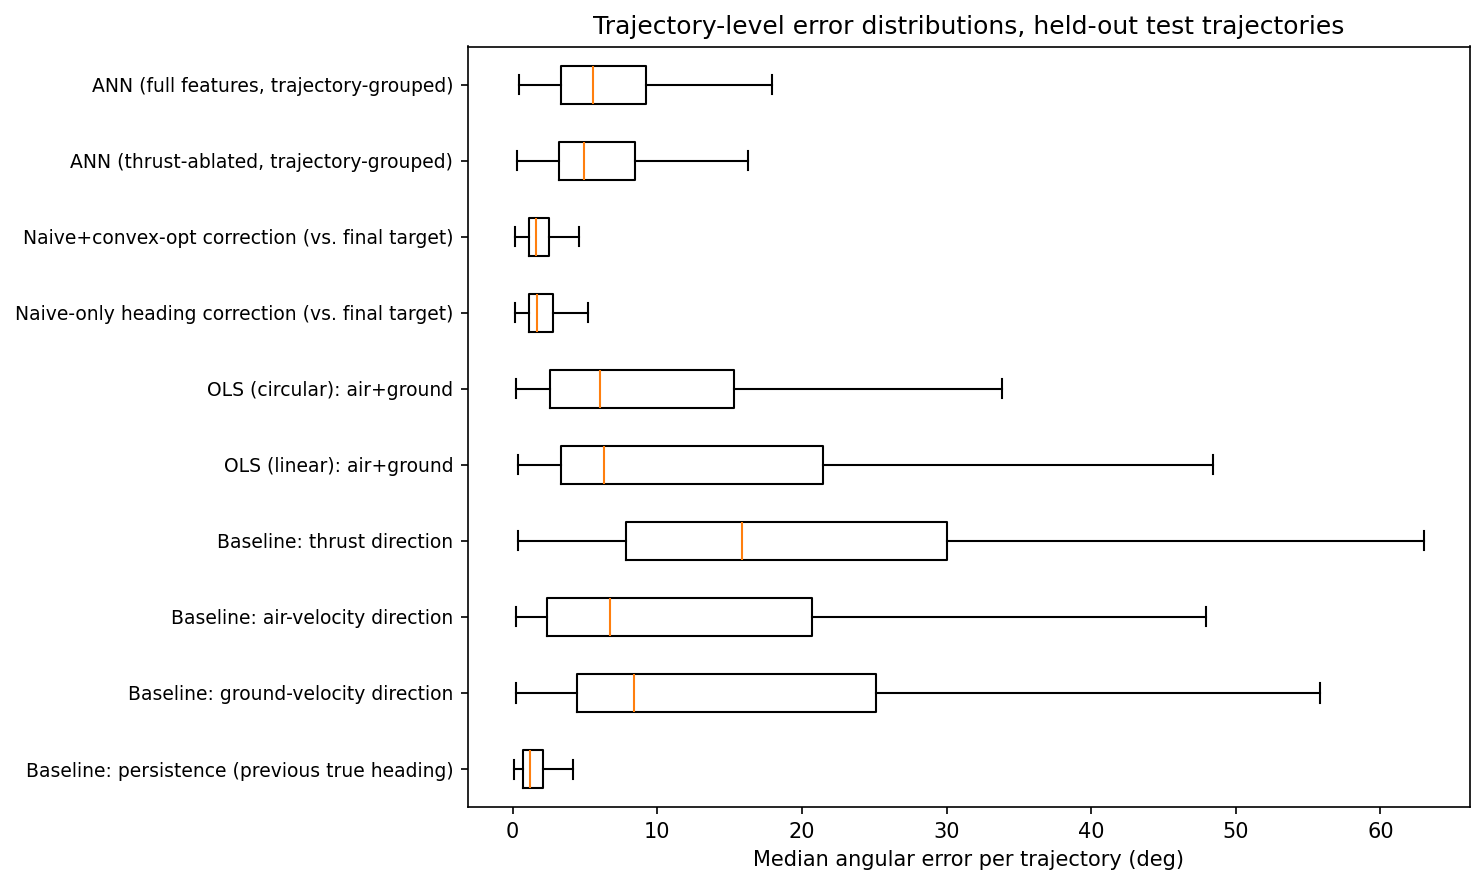

In [15]:
best_linear_label = min(
    (r for r in results_summary if r['model'].startswith('OLS (linear)')),
    key=lambda r: r['median_per_traj_error_deg'],
)['model']
best_circular_label = min(
    (r for r in results_summary if r['model'].startswith('OLS (circular)')),
    key=lambda r: r['median_per_traj_error_deg'],
)['model']

plot_labels = [
    'Baseline: persistence (previous true heading)',
    'Baseline: ground-velocity direction',
    'Baseline: air-velocity direction',
    'Baseline: thrust direction',
    best_linear_label,
    best_circular_label,
    'Naive-only heading correction (vs. final target)',
    'Naive+convex-opt correction (vs. final target)',
    'ANN (thrust-ablated, trajectory-grouped)',
    'ANN (full features, trajectory-grouped)',
]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
data = [per_traj_store[label].values for label in plot_labels]
ax.boxplot(data, vert=False, showfliers=False)
ax.set_yticklabels(plot_labels, fontsize=9)
ax.set_xlabel('Median angular error per trajectory (deg)')
ax.set_title('Trajectory-level error distributions, held-out test trajectories')
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_trajectory_error_boxplot.svg', format='svg')
plt.show()


> **Reading the table above:** at face value it ranks "ANN, no rotation augmentation",
> "ANN, thrust-ablated", and "ANN, no time-delay embedding" all above "ANN, full
> features" — do not take the first and third of those at face value. As detailed in
> Section 8's update note and in Parts 4-6, "no rotation augmentation" and "no
> time-delay embedding" only look better here because this table evaluates every model
> on the single real wind direction present in this dataset; both collapse badly when
> evaluated on wind directions not seen in training (Part 4), while the full model does
> not. The thrust-ablation result is unaffected by this issue (both the full and
> thrust-ablated models were trained with augmentation) and stands as reported.

> **What does survive this table, unaffected by the caveat above:** the thrust-ablation result (a fair, apples-to-apples comparison, since both the full and thrust-ablated models were trained with augmentation) and the full OLS/circular-regression family, which establishes that the ANN beats the best available closed-form alternative (6.02 deg) by a real margin. Both are strong, reviewer-relevant findings for the response letter; the unreliable rows are specifically the two flagged above, not the table as a whole.

## 14. Summary

This notebook does not modify `model_training.ipynb`, `models/model.keras`, or any file
under `pipelinedata/01_merged` through `pipelinedata/08_wind_augmented` — all new
artifacts are written to `models/model_reviewer_response_*.keras`,
`pipelinedata/reviewer_response/`, and `figures/reviewer_response_*`.

What this notebook establishes:

- A trajectory-grouped train/test split and grouped cross-validation, closing the
  leakage pathway raised by all three reviewers.
- A thrust-ablated model trained and evaluated under the identical (leakage-free)
  procedure, to quantify the label-circularity concern directly rather than argue about
  it qualitatively.
- Trajectory-level (not frame-pooled) error statistics with bootstrap confidence
  intervals and seed-to-seed variability, replacing the single frame-pooled point
  estimate the review criticized.
- A full quantitative baseline suite — kinematic direction baselines, a persistence
  model, the correction procedure's own outputs, and 14 linear/circular regression
  fits — establishing what a neural network needs to beat to be worth using.

What is deliberately **not** covered here (see `plan_for_addressing_some_concerns.txt`
for the "Strongly recommended" and "Manuscript/administrative" items): independent
validation of the corrected heading against a non-thrust-derived ground truth,
sensitivity analysis of the correction procedure's alpha2/alpha1 ratio, raw-vs-smoothed
prediction reporting, leave-one-wind-speed-out generalization tests, out-of-distribution
input warnings, and the manuscript-numbers/funding/data-availability reconciliation.
Those remain open items for a follow-up pass.